# DigitalWitness — Model Evaluation

Regenerates all thesis evaluation metrics for three models:
- **YOLO (`yolo26_dw_v2.pt`)** — 4-class frame-level behaviour detector
- **MobileNetV2 (`mobilenet_dw.pt`)** — binary frame-level classifier
- **BiLSTM+Attention (`bilstm_dw.pt`)** — sequence-level classifier

Metrics produced for each: Confusion Matrix · Accuracy · Precision · Recall · F1 · AUC-ROC

## 0 · Setup

In [1]:
import sys, json, os
from pathlib import Path

import numpy as np
import torch
import cv2
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from torchvision import transforms
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, ConfusionMatrixDisplay
)
from PIL import Image
from tqdm.auto import tqdm
from ultralytics import YOLO

# ── project root on the current machine ──────────────────────────────────────
ROOT      = Path(r'C:\Users\MSI\Music\Project_DigitalWitness')
MODELS    = ROOT / 'models'
FRAMES    = ROOT / 'frames'
YOLO_TEST = ROOT / 'data' / 'dataset' / 'test'

# ── path remapper (training paths used D:\Santosh\…) ─────────────────────────
OLD_ROOT = Path(r'D:\Santosh\Project_DigitalWitness')
def remap(p: str) -> Path:
    """Translate a training-machine absolute path to the current machine."""
    return ROOT / Path(p).relative_to(OLD_ROOT)

# ── reproducibility ───────────────────────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
print(f'ROOT   : {ROOT}')

# ── output folder for saved plots ─────────────────────────────────────────────
OUT_DIR = ROOT / 'outputs' / 'eval'
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'Plots  → {OUT_DIR}')

Device : cpu
ROOT   : C:\Users\MSI\Music\Project_DigitalWitness
Plots  → C:\Users\MSI\Music\Project_DigitalWitness\outputs\eval


c:\Users\MSI\Music\Project_DigitalWitness\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Shared plotting helpers

In [2]:
THESIS_PALETTE = sns.color_palette('muted')
sns.set_theme(style='whitegrid', palette=THESIS_PALETTE, font_scale=1.15)
plt.rcParams.update({'figure.dpi': 150})

def plot_confusion_matrix(cm, class_names, title, save_name, normalize=False):
    """Plot and save a labelled confusion matrix."""
    if normalize:
        cm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        fmt, vmax = '.2f', 1.0
    else:
        fmt, vmax = 'd', None

    fig, ax = plt.subplots(figsize=(max(4, len(class_names) * 1.8),
                                    max(3.5, len(class_names) * 1.6)))
    sns.heatmap(cm, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                vmin=0, vmax=vmax, linewidths=.5, ax=ax)
    ax.set_xlabel('Predicted label', fontsize=12)
    ax.set_ylabel('True label', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    fig.savefig(OUT_DIR / save_name, bbox_inches='tight')
    plt.show()
    print(f'Saved → {OUT_DIR / save_name}')


def plot_roc(fpr, tpr, roc_auc, title, save_name):
    """Plot and save a ROC curve."""
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    ax.plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc:.4f}')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.6)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(title, fontweight='bold')
    ax.legend(loc='lower right')
    ax.xaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
    ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
    plt.tight_layout()
    fig.savefig(OUT_DIR / save_name, bbox_inches='tight')
    plt.show()
    print(f'Saved → {OUT_DIR / save_name}')


def print_metrics(y_true, y_pred, class_names):
    """Print a formatted classification report."""
    print(classification_report(y_true, y_pred,
                                target_names=class_names, digits=4))


def load_json(path):
    with open(path) as f:
        return json.load(f)

---
## 1 · YOLO — 4-class Behaviour Detector

Model: `yolo26_dw_v2.pt`  
Classes: `looking-around (0)` · `picking-holding (1)` · `normal (2)` · `shoplifting (3)`  
Test set: `data/dataset/test/` (278 labelled images)

> No saved eval JSON exists for YOLO — metrics are computed from scratch.

In [3]:
# ── load the fine-tuned 4-class model ─────────────────────────────────────────
yolo_model = YOLO(str(MODELS / 'yolo26_dw_v2.pt'))
YOLO_CLASSES = ['looking-around', 'picking-holding', 'normal', 'shoplifting']

# Priority for resolving multi-object images to a single ground-truth label
# (mirrors the PRIORITY dict in video_processor.py)
PRIORITY = {'shoplifting': 3, 'looking-around': 2, 'picking-holding': 1, 'normal': 0}

print('YOLO model loaded:', MODELS / 'yolo26_dw_v2.pt')
print('Test images:', len(list((YOLO_TEST / 'images').glob('*.jpg'))))

YOLO model loaded: C:\Users\MSI\Music\Project_DigitalWitness\models\yolo26_dw_v2.pt
Test images: 278


In [4]:
def dominant_class_from_label(label_path: Path) -> int | None:
    """
    Read a YOLO-format label file and return the dominant class index.
    Dominance is decided by PRIORITY (shoplifting wins over everything else).
    Returns None for empty label files (background images).
    """
    lines = label_path.read_text().strip().splitlines()
    lines = [l for l in lines if l.strip()]
    if not lines:
        return None
    class_ids = [int(l.split()[0]) for l in lines]
    return max(class_ids, key=lambda c: PRIORITY.get(YOLO_CLASSES[c], 0))


def yolo_predict_dominant(img_path: Path) -> tuple[int, float]:
    """
    Run YOLO inference on one image and return (dominant_class_id, confidence).
    Dominant is the highest-priority detection above conf=0.20.
    Falls back to 'normal' (2) if no detection passes the threshold.
    """
    results = yolo_model.predict(str(img_path), conf=0.20, verbose=False)[0]
    if results.boxes is None or len(results.boxes) == 0:
        return 2, 0.0   # no detection → predict 'normal'

    best_cls, best_conf = 2, 0.0
    for cls_t, conf_t in zip(results.boxes.cls.cpu().numpy(),
                              results.boxes.conf.cpu().numpy()):
        c = int(cls_t)
        if PRIORITY.get(YOLO_CLASSES[c], 0) > PRIORITY.get(YOLO_CLASSES[best_cls], 0):
            best_cls, best_conf = c, float(conf_t)
        elif (PRIORITY.get(YOLO_CLASSES[c], 0) == PRIORITY.get(YOLO_CLASSES[best_cls], 0)
              and float(conf_t) > best_conf):
            best_cls, best_conf = c, float(conf_t)
    return best_cls, best_conf


# ── run evaluation ────────────────────────────────────────────────────────────
img_dir   = YOLO_TEST / 'images'
label_dir = YOLO_TEST / 'labels'

y_true_4cls, y_pred_4cls = [], []
skipped = 0

for img_path in tqdm(sorted(img_dir.glob('*.jpg')), desc='YOLO inference'):
    label_path = label_dir / img_path.with_suffix('.txt').name
    if not label_path.exists():
        skipped += 1
        continue
    gt = dominant_class_from_label(label_path)
    if gt is None:          # empty label file (background)
        skipped += 1
        continue
    pred, _ = yolo_predict_dominant(img_path)
    y_true_4cls.append(gt)
    y_pred_4cls.append(pred)

y_true_4cls = np.array(y_true_4cls)
y_pred_4cls = np.array(y_pred_4cls)
print(f'Evaluated {len(y_true_4cls)} images  |  Skipped {skipped} (empty labels)')

YOLO inference: 100%|██████████| 278/278 [00:11<00:00, 24.05it/s]

Evaluated 247 images  |  Skipped 31 (empty labels)


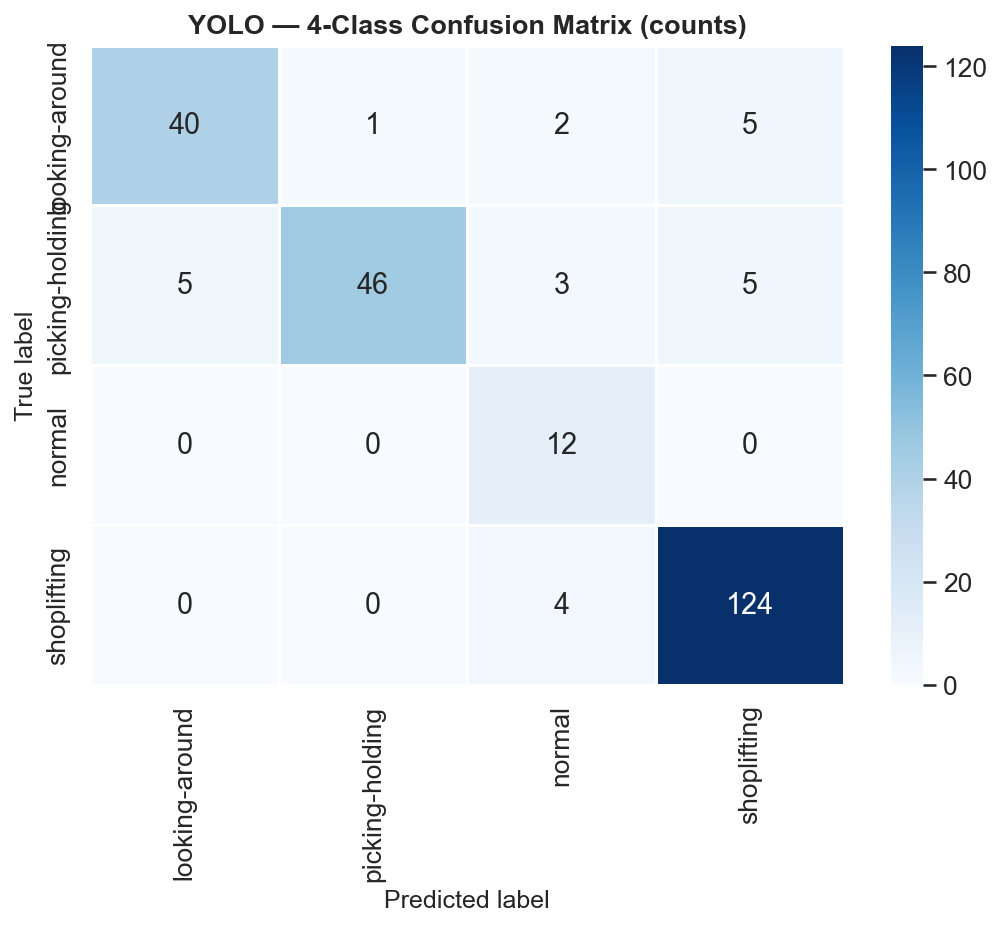

Saved → C:\Users\MSI\Music\Project_DigitalWitness\outputs\eval\yolo_confusion_matrix.png


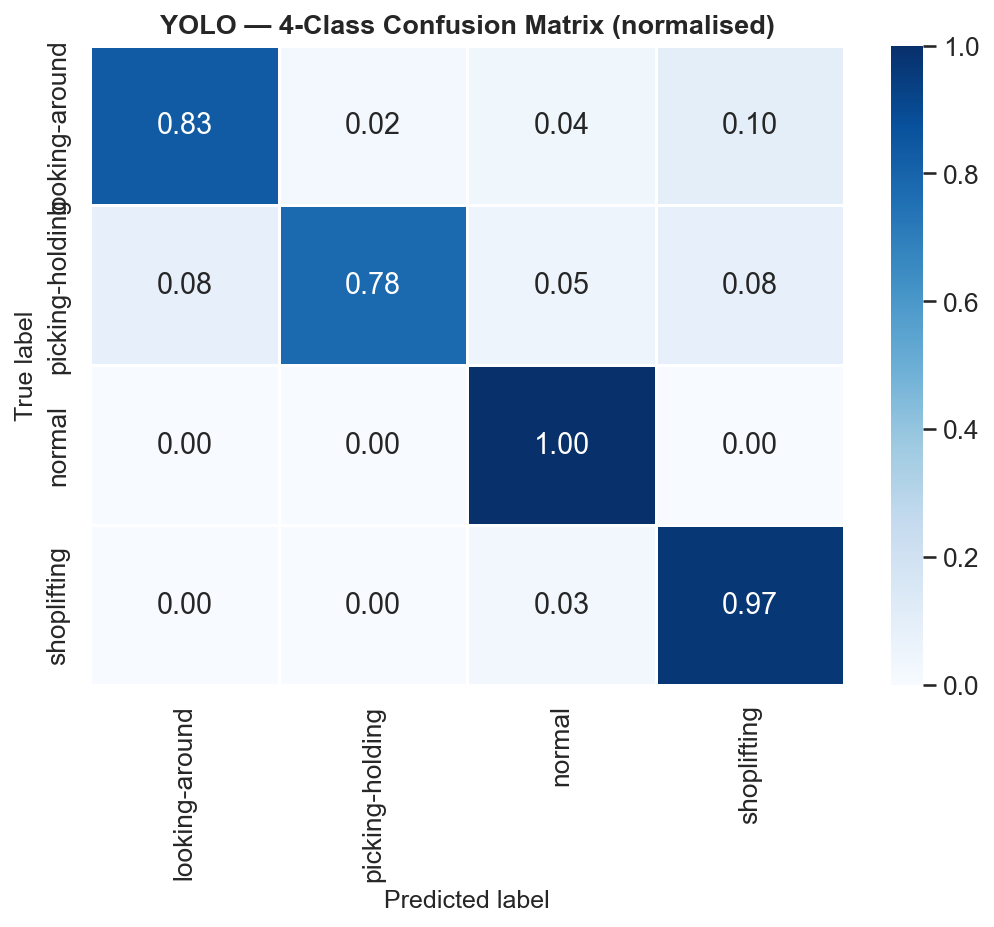

Saved → C:\Users\MSI\Music\Project_DigitalWitness\outputs\eval\yolo_confusion_matrix_norm.png


In [5]:
# ── 4-class confusion matrix ───────────────────────────────────────────────────
cm_yolo = confusion_matrix(y_true_4cls, y_pred_4cls, labels=[0,1,2,3])
plot_confusion_matrix(cm_yolo, YOLO_CLASSES,
                      title='YOLO — 4-Class Confusion Matrix (counts)',
                      save_name='yolo_confusion_matrix.png')
plot_confusion_matrix(cm_yolo, YOLO_CLASSES,
                      title='YOLO — 4-Class Confusion Matrix (normalised)',
                      save_name='yolo_confusion_matrix_norm.png',
                      normalize=True)

In [6]:
# ── 4-class classification report ─────────────────────────────────────────────
print('YOLO — 4-class report')
print('=' * 60)
print_metrics(y_true_4cls, y_pred_4cls, YOLO_CLASSES)

YOLO — 4-class report
                 precision    recall  f1-score   support

 looking-around     0.8889    0.8333    0.8602        48
picking-holding     0.9787    0.7797    0.8679        59
         normal     0.5714    1.0000    0.7273        12
    shoplifting     0.9254    0.9688    0.9466       128

       accuracy                         0.8988       247
      macro avg     0.8411    0.8954    0.8505       247
   weighted avg     0.9138    0.8988    0.9003       247



YOLO scores for ROC: 100%|██████████| 278/278 [00:12<00:00, 22.98it/s]


YOLO binary AUC-ROC (shoplifting vs rest): 0.9686


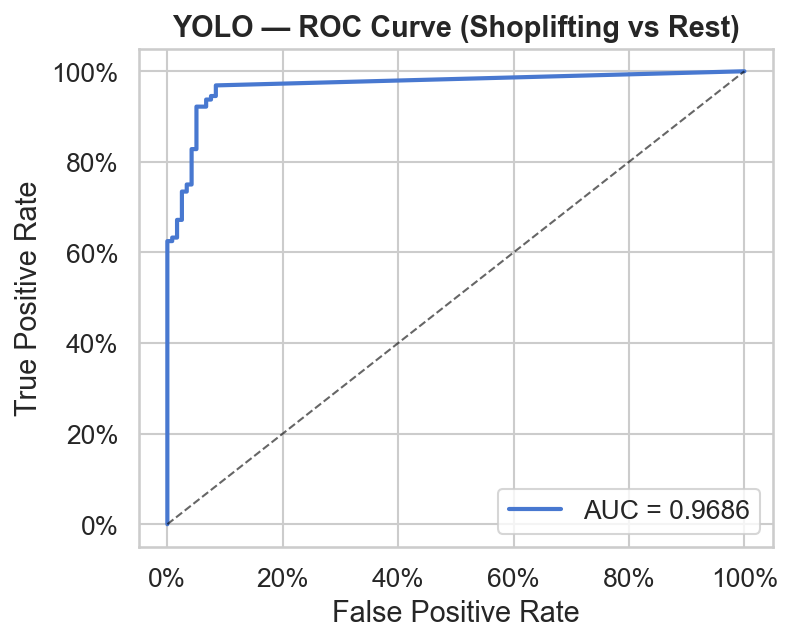

Saved → C:\Users\MSI\Music\Project_DigitalWitness\outputs\eval\yolo_roc_curve.png


In [7]:
# ── binary ROC (shoplifting vs rest) ──────────────────────────────────────────
# Collect shoplifting confidence scores for AUC computation
y_score_yolo = []
y_bin_true   = []

for img_path in tqdm(sorted(img_dir.glob('*.jpg')), desc='YOLO scores for ROC'):
    label_path = label_dir / img_path.with_suffix('.txt').name
    if not label_path.exists():
        continue
    gt = dominant_class_from_label(label_path)
    if gt is None:
        continue
    results = yolo_model.predict(str(img_path), conf=0.20, verbose=False)[0]
    # shoplifting score = max conf for class 3, else 0
    shop_score = 0.0
    if results.boxes is not None and len(results.boxes) > 0:
        for cls_t, conf_t in zip(results.boxes.cls.cpu().numpy(),
                                  results.boxes.conf.cpu().numpy()):
            if int(cls_t) == 3:   # shoplifting
                shop_score = max(shop_score, float(conf_t))
    y_score_yolo.append(shop_score)
    y_bin_true.append(1 if gt == 3 else 0)

y_score_yolo = np.array(y_score_yolo)
y_bin_true   = np.array(y_bin_true)

fpr_y, tpr_y, _ = roc_curve(y_bin_true, y_score_yolo)
auc_y = auc(fpr_y, tpr_y)
print(f'YOLO binary AUC-ROC (shoplifting vs rest): {auc_y:.4f}')
plot_roc(fpr_y, tpr_y, auc_y,
         title='YOLO — ROC Curve (Shoplifting vs Rest)',
         save_name='yolo_roc_curve.png')

---
## 2 · MobileNetV2 — Frame-Level Binary Classifier

Model: `mobilenet_dw.pt`  
Classes: `normal (0)` · `shoplifting (1)`  
Test set: 9 363 frames from `mobilenet_test_split.json`

> Saved metrics from `mobilenet_eval.json` are reproduced + AUC-ROC is computed.

In [8]:
# ── add project root to sys.path so core.* imports work ──────────────────────
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from core.model_definitions import MobileNetExtractor

# ── load checkpoint ───────────────────────────────────────────────────────────
ckpt = torch.load(MODELS / 'mobilenet_dw.pt', map_location=DEVICE, weights_only=False)
sd   = ckpt.get('state_dict', ckpt) if isinstance(ckpt, dict) else ckpt
mobilenet = MobileNetExtractor().to(DEVICE)
mobilenet.load_state_dict(sd)
mobilenet.eval()
print('MobileNetV2 loaded')

# ── saved metrics (shown for reference) ───────────────────────────────────────
mob_eval = load_json(MODELS / 'mobilenet_eval.json')
mob_info = load_json(MODELS / 'mobilenet_dw_info.json')
print('\nSaved eval metrics (mobilenet_eval.json):')
for k, v in mob_eval.items():
    print(f'  {k}: {v}')

# ── image preprocessing (must match training exactly) ─────────────────────────
MN_TRANSFORM = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

BINARY_CLASSES = ['normal', 'shoplifting']

MobileNetV2 loaded

Saved eval metrics (mobilenet_eval.json):
  model: MobileNetV2
  test_samples: 9363
  accuracy: 0.9953006515005874
  precision: 0.9953545491188599
  recall: 0.9953006515005874
  f1_score: 0.9953075669679282
  confusion_matrix: [[3203, 2], [42, 6116]]


In [9]:
# ── load test split and remap paths ───────────────────────────────────────────
mob_split  = load_json(MODELS / 'mobilenet_test_split.json')
mob_paths  = [remap(p) for p in mob_split['paths']]
mob_labels = mob_split['labels']

# quick sanity check
existing = sum(1 for p in mob_paths if p.exists())
print(f'Test frames : {len(mob_paths):,}  |  Found on disk : {existing:,}')
assert existing == len(mob_paths), 'Some test frames are missing!'

Test frames : 9,363  |  Found on disk : 9,363


In [ ]:
# ── inference loop ────────────────────────────────────────────────────────────
y_true_mob, y_pred_mob, y_score_mob = [], [], []

BATCH = 64

with torch.no_grad():
    for start in tqdm(range(0, len(mob_paths), BATCH), desc='MobileNet inference'):
        batch_paths  = mob_paths[start:start + BATCH]
        batch_labels = mob_labels[start:start + BATCH]

        imgs = []
        for p in batch_paths:
            img = Image.open(p).convert('RGB')
            imgs.append(MN_TRANSFORM(img))

        x      = torch.stack(imgs).to(DEVICE)
        logits = mobilenet(x)                     # uses the classifier head
        probs  = torch.softmax(logits, dim=1).cpu().numpy()

        preds = np.argmax(probs, axis=1)
        y_true_mob.extend(batch_labels)
        y_pred_mob.extend(preds.tolist())
        y_score_mob.extend(probs[:, 1].tolist())  # shoplifting probability

y_true_mob  = np.array(y_true_mob)
y_pred_mob  = np.array(y_pred_mob)
y_score_mob = np.array(y_score_mob)
print(f'Done — {len(y_true_mob):,} samples')

MobileNet inference:  29%|██▉       | 43/147 [01:08<02:42,  1.57s/it]

In [ ]:
# ── confusion matrix ──────────────────────────────────────────────────────────
cm_mob = confusion_matrix(y_true_mob, y_pred_mob)
plot_confusion_matrix(cm_mob, BINARY_CLASSES,
                      title='MobileNetV2 — Confusion Matrix (counts)',
                      save_name='mobilenet_confusion_matrix.png')
plot_confusion_matrix(cm_mob, BINARY_CLASSES,
                      title='MobileNetV2 — Confusion Matrix (normalised)',
                      save_name='mobilenet_confusion_matrix_norm.png',
                      normalize=True)

In [ ]:
# ── classification report ─────────────────────────────────────────────────────
print('MobileNetV2 — classification report')
print('=' * 60)
print_metrics(y_true_mob, y_pred_mob, BINARY_CLASSES)

In [ ]:
# ── ROC curve ─────────────────────────────────────────────────────────────────
fpr_m, tpr_m, _ = roc_curve(y_true_mob, y_score_mob)
auc_m = auc(fpr_m, tpr_m)
print(f'MobileNetV2 AUC-ROC: {auc_m:.4f}')
plot_roc(fpr_m, tpr_m, auc_m,
         title='MobileNetV2 — ROC Curve',
         save_name='mobilenet_roc_curve.png')

---
## 3 · BiLSTM+Attention — Sequence-Level Classifier

Model: `bilstm_dw.pt` (uses `mobilenet_extractor.pt` to rebuild feature sequences)  
Classes: `normal (0)` · `shoplifting (1)`  
Test set: 27 video sequences from `bilstm_test_split.json`

The `.npy` sequence files were deleted, so this section **rebuilds them on-the-fly** from the existing frame images in `frames/`.

> Saved metrics from `bilstm_eval.json` are reproduced + AUC-ROC is computed.

In [ ]:
from core.model_definitions import BiLSTMAttentionClassifier

# ── load MobileNet extractor (feature extraction only) ────────────────────────
ext_ckpt = torch.load(MODELS / 'mobilenet_extractor.pt', map_location=DEVICE, weights_only=False)
ext_sd   = ext_ckpt.get('state_dict', ext_ckpt) if isinstance(ext_ckpt, dict) else ext_ckpt
extractor = MobileNetExtractor().to(DEVICE)
extractor.load_state_dict(ext_sd)
extractor.eval()
print('Feature extractor loaded')

# ── load BiLSTM ───────────────────────────────────────────────────────────────
lstm_ckpt = torch.load(MODELS / 'bilstm_dw.pt', map_location=DEVICE, weights_only=False)
lstm_sd   = lstm_ckpt.get('state_dict', lstm_ckpt) if isinstance(lstm_ckpt, dict) else lstm_ckpt
bilstm = BiLSTMAttentionClassifier(num_classes=2, hidden=256, layers=2, dropout=0.3).to(DEVICE)
bilstm.load_state_dict(lstm_sd)
bilstm.eval()
print('BiLSTM loaded')

# ── saved metrics (shown for reference) ───────────────────────────────────────
lstm_eval = load_json(MODELS / 'bilstm_eval.json')
lstm_info = load_json(MODELS / 'bilstm_dw_info.json')
print('\nSaved eval metrics (bilstm_eval.json):')
for k, v in lstm_eval.items():
    print(f'  {k}: {v}')

# ── hyper-parameters (must match training) ────────────────────────────────────
SEQ_LEN    = lstm_info.get('seq_len', 45)
FEAT_STEP  = 4      # extract features every 4th frame
LSTM_TEMP  = 3.0    # temperature scaling used in BehaviourClassifier

In [ ]:
# ── frame-to-feature helper ───────────────────────────────────────────────────
FE_TRANSFORM = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

@torch.no_grad()
def frames_to_features(frame_paths: list[Path]) -> np.ndarray:
    """
    Read FEAT_STEP-sampled frames, extract MobileNet features.
    Returns ndarray of shape (N, 1280).
    """
    sampled = frame_paths[::FEAT_STEP]   # every 4th frame
    feats = []
    for p in sampled:
        bgr   = cv2.imread(str(p))
        rgb   = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        x     = FE_TRANSFORM(rgb).unsqueeze(0).to(DEVICE)
        feat  = extractor.extract_features(x).cpu().numpy().flatten()
        feats.append(feat)
    return np.array(feats) if feats else np.zeros((1, 1280), dtype=np.float32)


@torch.no_grad()
def classify_sequence(features: np.ndarray) -> tuple[int, float, float]:
    """
    Sliding-window BiLSTM inference.  Returns:
      (predicted_class, shoplifting_probability, confidence)
    using majority voting + averaged probabilities across windows.
    """
    if len(features) < SEQ_LEN:
        pad      = np.zeros((SEQ_LEN - len(features), 1280), dtype=np.float32)
        features = np.vstack([features, pad])

    all_shop_probs = []
    for start in range(0, len(features) - SEQ_LEN + 1, 15):   # stride=15
        seq  = features[start:start + SEQ_LEN]
        x    = torch.FloatTensor(seq[np.newaxis]).to(DEVICE)
        logits, _ = bilstm(x)
        probs     = torch.softmax(logits / LSTM_TEMP, dim=1).cpu().numpy()[0]
        all_shop_probs.append(probs[1])   # index 1 = shoplifting

    avg_shop = float(np.mean(all_shop_probs))
    pred     = 1 if avg_shop >= 0.5 else 0
    return pred, avg_shop, float(np.max(all_shop_probs))

In [ ]:
# ── load test split and find matching frame directories ───────────────────────
lstm_split  = load_json(MODELS / 'bilstm_test_split.json')
lstm_paths  = lstm_split['paths']
lstm_labels = lstm_split['labels']

# ── evaluate each sequence ────────────────────────────────────────────────────
y_true_lstm, y_pred_lstm, y_score_lstm = [], [], []

for npy_path, label in tqdm(zip(lstm_paths, lstm_labels),
                             total=len(lstm_paths), desc='BiLSTM sequences'):
    stem      = Path(npy_path).stem                           # e.g. 'shoplifting-21'
    cls_name  = 'shoplifting' if label == 1 else 'normal'
    frame_dir = FRAMES / cls_name

    # collect & sort all frames belonging to this video
    frame_paths = sorted(
        frame_dir.glob(f'{stem}_frame_*.jpg'),
        key=lambda p: int(p.stem.rsplit('_', 1)[-1])   # sort by frame number
    )

    if not frame_paths:
        print(f'  WARNING: no frames found for {stem} — skipping')
        continue

    feats                = frames_to_features(frame_paths)
    pred, shop_prob, _   = classify_sequence(feats)

    y_true_lstm.append(label)
    y_pred_lstm.append(pred)
    y_score_lstm.append(shop_prob)

y_true_lstm  = np.array(y_true_lstm)
y_pred_lstm  = np.array(y_pred_lstm)
y_score_lstm = np.array(y_score_lstm)
print(f'Done — {len(y_true_lstm)} sequences evaluated')

In [ ]:
# ── confusion matrix ──────────────────────────────────────────────────────────
cm_lstm = confusion_matrix(y_true_lstm, y_pred_lstm)
plot_confusion_matrix(cm_lstm, BINARY_CLASSES,
                      title='BiLSTM+Attention — Confusion Matrix (counts)',
                      save_name='bilstm_confusion_matrix.png')
plot_confusion_matrix(cm_lstm, BINARY_CLASSES,
                      title='BiLSTM+Attention — Confusion Matrix (normalised)',
                      save_name='bilstm_confusion_matrix_norm.png',
                      normalize=True)

In [ ]:
# ── classification report ─────────────────────────────────────────────────────
print('BiLSTM+Attention — classification report')
print('=' * 60)
print_metrics(y_true_lstm, y_pred_lstm, BINARY_CLASSES)

In [ ]:
# ── ROC curve ─────────────────────────────────────────────────────────────────
fpr_l, tpr_l, _ = roc_curve(y_true_lstm, y_score_lstm)
auc_l = auc(fpr_l, tpr_l)
print(f'BiLSTM AUC-ROC: {auc_l:.4f}')
plot_roc(fpr_l, tpr_l, auc_l,
         title='BiLSTM+Attention — ROC Curve',
         save_name='bilstm_roc_curve.png')

---
## 4 · Summary Comparison

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ── compute per-model summary metrics ─────────────────────────────────────────
def summary_row(name, y_true, y_pred, y_score, multiclass=False):
    avg = 'macro' if multiclass else 'binary'
    # AUC-ROC: binary only (shoplifting vs rest)
    if multiclass:
        bin_true  = (y_true == 3).astype(int)   # shoplifting class index in YOLO
        roc_score = auc(*roc_curve(bin_true, y_score)[:2])
    else:
        roc_score = auc(*roc_curve(y_true, y_score)[:2])
    return {
        'Model'    : name,
        'Accuracy' : accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average=avg, zero_division=0),
        'Recall'   : recall_score(y_true, y_pred, average=avg, zero_division=0),
        'F1'       : f1_score(y_true, y_pred, average=avg, zero_division=0),
        'AUC-ROC'  : roc_score,
    }

rows = [
    summary_row('YOLO (4-class)',        y_true_4cls,  y_pred_4cls,  y_score_yolo, multiclass=True),
    summary_row('MobileNetV2 (binary)',  y_true_mob,   y_pred_mob,   y_score_mob),
    summary_row('BiLSTM+Attn (binary)',  y_true_lstm,  y_pred_lstm,  y_score_lstm),
]

# ── display as a formatted table ──────────────────────────────────────────────
print(f'{'Model':<28} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'AUC-ROC':>10}')
print('-' * 80)
for r in rows:
    print(f"{r['Model']:<28} {r['Accuracy']:>10.4f} {r['Precision']:>10.4f}"
          f" {r['Recall']:>10.4f} {r['F1']:>10.4f} {r['AUC-ROC']:>10.4f}")

In [ ]:
# ── combined ROC overlay ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))

# YOLO — shoplifting vs rest
ax.plot(fpr_y, tpr_y, lw=2,
        label=f'YOLO 4-class (AUC = {auc_y:.4f})')

# MobileNet
ax.plot(fpr_m, tpr_m, lw=2,
        label=f'MobileNetV2 (AUC = {auc_m:.4f})')

# BiLSTM
ax.plot(fpr_l, tpr_l, lw=2,
        label=f'BiLSTM+Attn (AUC = {auc_l:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models', fontweight='bold')
ax.legend(loc='lower right')
ax.xaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
plt.tight_layout()
fig.savefig(OUT_DIR / 'combined_roc_curves.png', bbox_inches='tight')
plt.show()
print(f'Saved → {OUT_DIR / "combined_roc_curves.png"}')

In [ ]:
# ── save summary metrics to JSON (for easy re-use) ────────────────────────────
summary = {
    'yolo': {
        'model'          : 'YOLO yolo26_dw_v2.pt (4-class)',
        'test_images'    : int(len(y_true_4cls)),
        'classes'        : YOLO_CLASSES,
        'accuracy'       : float(rows[0]['Accuracy']),
        'precision_macro': float(rows[0]['Precision']),
        'recall_macro'   : float(rows[0]['Recall']),
        'f1_macro'       : float(rows[0]['F1']),
        'auc_roc_shoplifting_vs_rest': float(rows[0]['AUC-ROC']),
        'confusion_matrix': cm_yolo.tolist(),
    },
    'mobilenet': {
        'model'          : 'MobileNetV2 mobilenet_dw.pt (binary)',
        'test_samples'   : int(len(y_true_mob)),
        'classes'        : BINARY_CLASSES,
        'accuracy'       : float(rows[1]['Accuracy']),
        'precision'      : float(rows[1]['Precision']),
        'recall'         : float(rows[1]['Recall']),
        'f1_score'       : float(rows[1]['F1']),
        'auc_roc'        : float(rows[1]['AUC-ROC']),
        'confusion_matrix': cm_mob.tolist(),
    },
    'bilstm': {
        'model'          : 'BiLSTM+Attention bilstm_dw.pt (binary)',
        'test_sequences' : int(len(y_true_lstm)),
        'classes'        : BINARY_CLASSES,
        'accuracy'       : float(rows[2]['Accuracy']),
        'precision'      : float(rows[2]['Precision']),
        'recall'         : float(rows[2]['Recall']),
        'f1_score'       : float(rows[2]['F1']),
        'auc_roc'        : float(rows[2]['AUC-ROC']),
        'confusion_matrix': cm_lstm.tolist(),
    },
}

out_json = OUT_DIR / 'all_models_eval.json'
with open(out_json, 'w') as f:
    json.dump(summary, f, indent=2)
print(f'Full metrics saved → {out_json}')